# Loading Supermarket & Shopping list

In [1]:
from supermarket import Grid
from shopping_list import ShoppingList
import distance

grid = Grid("supermarket-grids/grid_eng.txt")
shopping_list = ShoppingList.load_from_file("shopping-lists/long_shopping_list.txt")
J_product_category, P_product_category, product_type_indizes = distance.compute_optimal_trajectories(grid, (5,4), (5,0))
J_product, P_product = distance.create_product_cost_path_matrix(shopping_list, J_product_category, P_product_category, product_type_indizes)


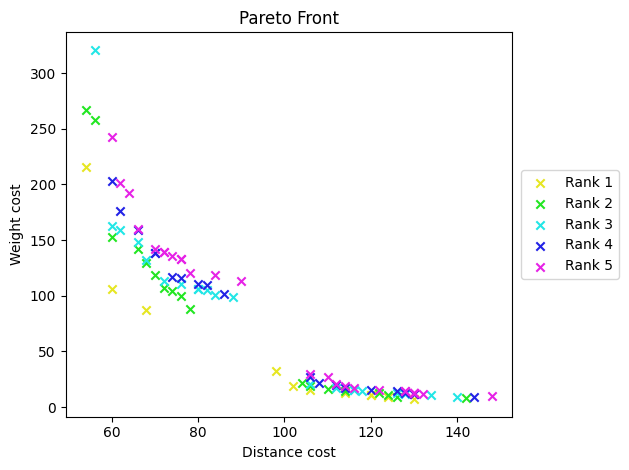

In [2]:
import distance
import weight
import evolution_2d

m = 1000
weight_costs, distance_costs = [], []
for i in range(m):
    if i < m/2:
        order = weight.generate_weightgreedy_random_order(shopping_list, alpha = 0.5)
    else:
        order = distance.generate_distancegreedy_random_order(J_product, alpha = 0.5)
    weight_cost = weight.compute_weight_cost(order, shopping_list)
    weight_costs.append(weight_cost)
    distance_cost = distance.compute_timecost_from_middle_indices_order(order, J_product)
    distance_costs.append(distance_cost)
import matplotlib.pyplot as plt
final_ranking, ranks, crowding_distances = evolution_2d.pareto_rank_2_with_crowding(distance_costs, weight_costs)
evolution_2d.plot_pareto_2(ranks, distance_costs, weight_costs, xlabel="Distance cost", ylabel="Weight cost", max_legend_ranks=6, plot_high_ranks=False)


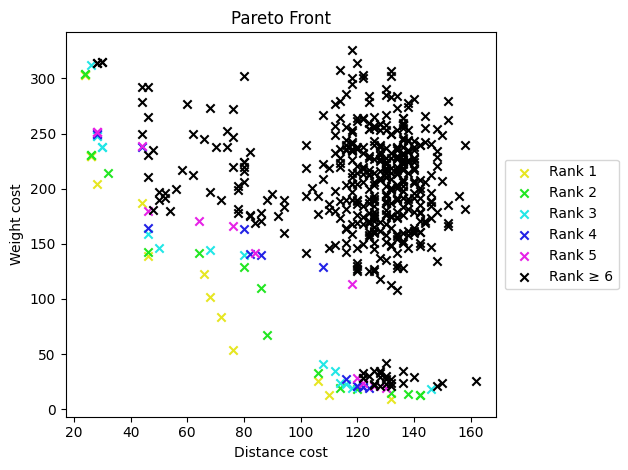

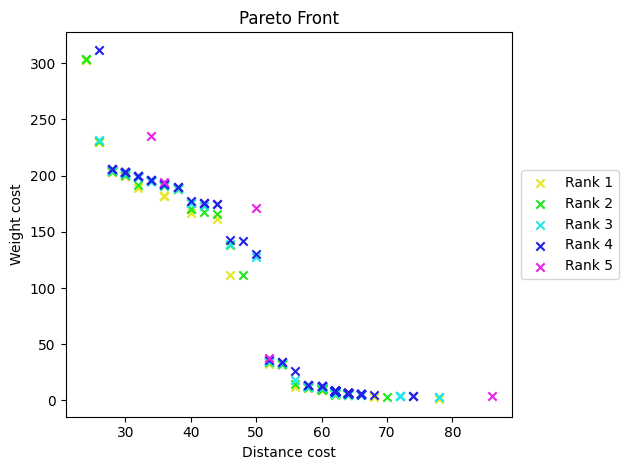

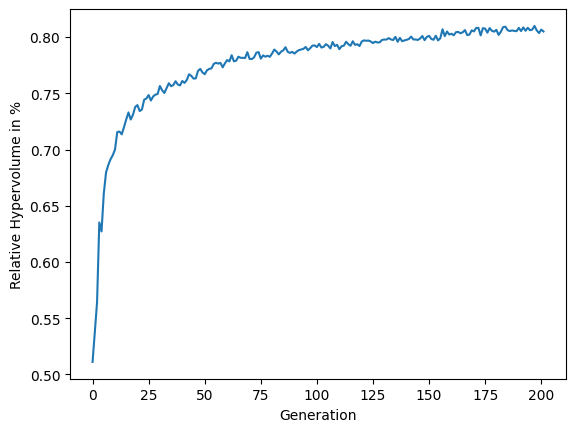

In [3]:
import hypervolume as hp

reference_point = (200, 400)
population, pareto_ranks, weight_costs, distance_costs, hypervolume_list, reference_point, history_list = evolution_2d.evolution_2d(
            shopping_list, J_product, patience=10, generation_size=100, population_size=500, reference_point=reference_point, history=True)
evolution_2d.plot_pareto_2(pareto_ranks, distance_costs, weight_costs, xlabel="Distance cost", ylabel="Weight cost",
               max_legend_ranks=6, plot_high_ranks=False, reference_point=None, saving_path="Final_pareto_front.jpg")

hp.plot_hypervolume(hypervolume_list, saving_path="hypervolume.jpg")


In [ ]:
import creating_gif
#creating_gif.create_pareto_gif_from_history(history_list, filename="assets/pareto_evolution.gif", duration=0.5)

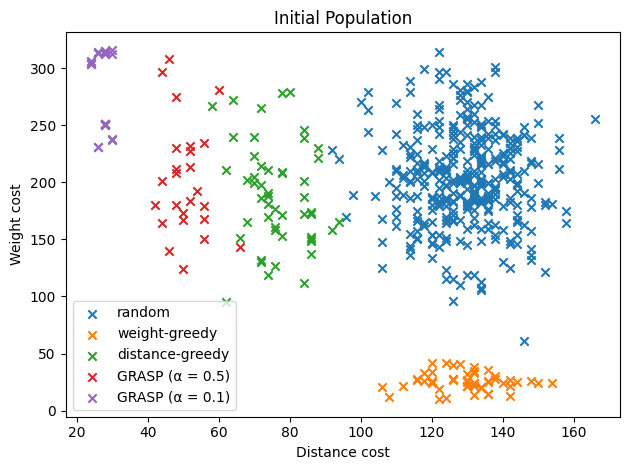

In [5]:
import plotting
# Visualize initial population
def plot_initial_population(population, population_label, xlabel="Cost x", ylabel="Cost y", saving_path=None):
    _, _, _, _, weight_costs, distance_costs = evolution_2d.evaluate_population_2d(
        population, shopping_list, J_product
    )

    # ---- Indizes nach Label gruppieren ----
    label_to_indices = {}
    for i, label in enumerate(population_label):
        if label not in label_to_indices:
            label_to_indices[label] = []
        label_to_indices[label].append(i)

    plt.figure()

    # ---- Über alle Sublists loopen ----
    for label, indices in label_to_indices.items():
        x_vals = [distance_costs[i] for i in indices]
        y_vals = [weight_costs[i] for i in indices]

        plt.scatter(
            x_vals,
            y_vals,
            label=label,
            marker="x"
        )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title("Initial Population")
    plt.legend()
    plt.tight_layout()

    if saving_path is not None:
        saving_path = plotting.check_saving_path(saving_path)
        plt.savefig(saving_path, bbox_inches="tight", dpi=400)

population, population_label = evolution_2d.initialize_population_2d(population_size=500, shopping_list=shopping_list, J_product=J_product)
plot_initial_population(population, population_label, xlabel="Distance cost", ylabel="Weight cost", saving_path="Initial_population_distribition.jpg")
